### Agentic RAG: Retrieval, Relevance Grading, and Query Rewriting

This notebook demonstrates an agentic retrieval-augmented generation (RAG) workflow using LangGraph and Groq.

It includes:
- document ingestion and vector store creation with OpenAI embeddings
- a tool-enabled agent that decides when to retrieve evidence
- document relevance grading to decide whether retrieval results are useful
- a query rewrite path for vague or poorly matched user inputs
- a generated answer path when retrieved information is deemed relevant

Use this notebook to explore how conditional graph routing can improve retrieval accuracy and help the agent recover from weak queries.

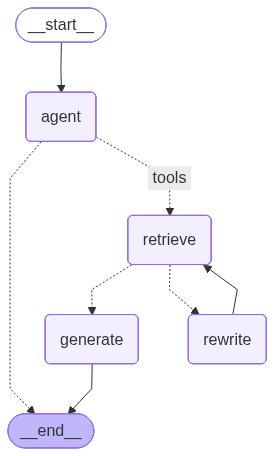

In [ ]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()




In [ ]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [ ]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

In [ ]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

In [ ]:
# Retriever to retriever tool

from langchain_core.tools import tool

@tool
def langchain_retriever_tool_func(query:str)->str:
    """Use this tool to fetch the relevant information about LangChain"""
    docs=retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [ ]:
### 1. Document Processing for Lillog

urls=[
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
    "https://lilianweng.github.io/posts/2024-02-05-human-data-quality/"
]

loaders = [WebBaseLoader(url) for url in urls]

lillog_docs=[]

for loader in loaders:
    lillog_docs.extend(loader.load())

lillog_docs

In [ ]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(lillog_docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

In [ ]:
# Retriever to retriever tool

from langchain_core.tools import tool

@tool
def lilog_retriever_tool_func(query:str)->str:
    """Use this tool to fetch the relevant information about relevant knowledge base"""
    docs=retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [ ]:
### Combine all the tools
tools =[lilog_retriever_tool_func,langchain_retriever_tool_func]

In [ ]:
# Create agent State
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # messages is a list-like collection of LangChain message objects.[HumanMessage(...), AIMessage(...),ToolMessage(...)]

In [ ]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given the question, it will decide to retrieve using the retriever tool or simply end.

    Args: state(messages): The current state

    Return: The updated state with agent response appended to messages
    
    """

    print("CALL Agent Node")

    messages = state['messages']

    os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

    # Properly bind tools to the model and invoke
    model_with_tools = llm.bind_tools(tools)
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [ ]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3-32b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="qwen/qwen3-32b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [ ]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]

    question = None
    for message in messages:
        if isinstance(message, HumanMessage):
            question = message.content
            break

    if not question:
        question = str(messages[-1].content) if messages else ""

    rewritten_prompt = PromptTemplate(
        input_variables=["question"],
        template=(
            "You are an expert at rewriting user queries to improve clarity and retrieval relevance.\n"
            "Transform the following question into a clearer, more specific, and more detailed question.\n\n"
            "Original question:\n{question}\n\n"
            "Provide only the rewritten question without any additional explanation."
        ),
    )

    prompt_text = rewritten_prompt.format(question=question)
    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke([HumanMessage(content=prompt_text)])
    rewritten_question = getattr(response, "content", str(response)).strip()

    print("Rewritten question:", rewritten_question)
    return {"messages": [HumanMessage(content=rewritten_question)]}


In [ ]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([langchain_retriever_tool_func, lilog_retriever_tool_func])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

# Route after retrieval based on relevance outcome
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate": "generate",
        "rewrite": "rewrite",
    },
)

# After generate, end
workflow.add_edge("generate", END)

# After rewrite, retry retrieval with the rewritten question
workflow.add_edge("rewrite", "retrieve")

# Compile
graph = workflow.compile()

# View the graph
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# Example: Show retrieved documents and relevance score for a vague question (triggers rewrite flow)
print("\n" + "="*60)
print("Example: Retrieved docs + relevance score")
print("="*60)

question = "langchain Integration"
print(f"\nQuery: {question}\n")

initial_state = {"messages": [HumanMessage(content=question)]}

# Invoke the compiled graph
result = graph.invoke(initial_state)

print('\n--- Execution Messages ---')
for i, msg in enumerate(result['messages']):
    msg_type = type(msg).__name__
    print(f"\nStep {i}: {msg_type}")

    # Tools called
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        try:
            tools_called = [tc.name for tc in msg.tool_calls]
        except Exception:
            tools_called = list(msg.tool_calls)
        print(f"  → Tools called: {tools_called}")

    # Content preview
    content = getattr(msg, 'content', None)
    if content is not None:
        text = str(content)
        preview = text[:800]
        print(f"  → Content preview:\n{preview}\n")

    # Relevance extraction (pydantic model, dict, or plain text)
    rel = None
    if isinstance(msg, dict) and 'relevant' in msg:
        rel = msg['relevant']
    else:
        try:
            if hasattr(msg, 'dict'):
                d = msg.dict()
                if 'relevant' in d:
                    rel = d['relevant']
        except Exception:
            pass
        # Fallback: look for literal '"relevant":' in text
        if rel is None and content:
            low = text.lower()
            if '"relevant"' in low or 'relevant' in low:
                # crude heuristic
                if 'yes' in low:
                    rel = 'yes'
                elif 'no' in low:
                    rel = 'no'

    if rel is not None:
        print(f"  → Relevance score: {rel}")

    # If this message contains retrieved docs (from retriever tool), print a separator
    if hasattr(msg, 'tool_calls') and msg.tool_calls and content:
        print('  ---- Retrieved Documents (full) ----')
        print(text)
        print('  ---- end documents ----')

print('\n--- End of Execution ---\n')